# Hypothesis Testing – Z-Test and t-Test
### One-tailed (Left & Right) and Two-tailed tests, explained with Python

**Contents**
1. Types of hypothesis tests (the diagram)
2. Key terms and the 5 steps
3. Z-test vs t-test – which one to use
4. Seeing the three tails
5. **Part A – Z-test:** left-tail, right-tail, two-tailed examples
6. **Part B – t-test:** left-tail, right-tail, two-tailed examples
7. Summary table, common mistakes and practice questions

> Run the cells from top to bottom with **Shift + Enter**.

## 1. Types of Hypothesis Tests

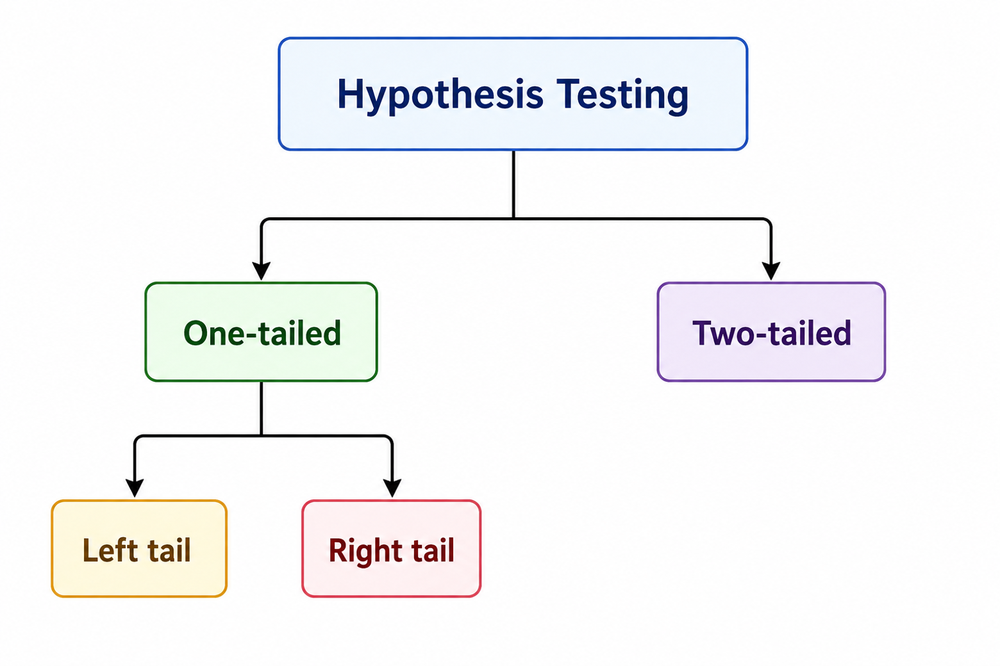

Every hypothesis test compares two statements about a population:

- **Null hypothesis $H_0$** – the default claim ("no change", "equal to"). Always contains **=**.
- **Alternative hypothesis $H_1$** – what we want to find evidence for.

**The direction of $H_1$ decides which branch of the diagram we use:**

| Branch | $H_1$ | Keywords in the question | Where we reject $H_0$ |
|---|---|---|---|
| **One-tailed → Left tail** | $\mu < \mu_0$ | *less than, decreased, below, fewer, at least is false* | Only the **left** end of the curve |
| **One-tailed → Right tail** | $\mu > \mu_0$ | *more than, increased, above, improved, exceeds* | Only the **right** end of the curve |
| **Two-tailed** | $\mu \neq \mu_0$ | *different, changed, not equal, differs* | **Both** ends of the curve (α is split in half) |

💡 **One-tailed** = we care about a change in **one specific direction**.
**Two-tailed** = we care about a change in **either direction**.



## 2. Key Terms and the 5 Steps

| Term | Meaning |
|---|---|
| **Significance level α** | The risk we accept of rejecting a true $H_0$ (usually **0.05**) |
| **Test statistic** | How many standard errors the sample mean is away from $\mu_0$ ($z$ or $t$) |
| **Critical value** | The cut-off point that starts the rejection region |
| **p-value** | Probability of getting a result this extreme (in the direction of $H_1$), **if $H_0$ is true** |

**The 5 steps**
1. State $H_0$ and $H_1$ → this tells you **left, right or two-tailed**
2. Choose α (0.05)
3. Compute the test statistic ($z$ or $t$)
4. Find the p-value (or critical value) **for your tail**
5. Decide: **p-value ≤ α → Reject $H_0$**, otherwise **Fail to reject $H_0$**, and write the conclusion in words



![Test Image](test.png)

# Hypothesis Testing

## 1. Hypotheses

- **Null Hypothesis ($H_0$):** The existing or claimed condition is true.
- **Alternative Hypothesis ($H_1$):** There is sufficient evidence that the claim is different.

For a two-tailed test:

$$
H_0:\mu=\mu_0
$$

$$
H_1:\mu\neq\mu_0
$$

---

## 2. Significance Level

$$
\boxed{\alpha=\text{Level of Significance}}
$$

- $\alpha$ is the probability of making a **Type I Error**.
- Common values are **0.05** and **0.01**.

### Type I Error

> Rejecting $H_0$ when $H_0$ is actually true.

---

## 3. Confidence Level

$$
\boxed{1-\alpha=\text{Confidence Level}}
$$

For example, if:

$$
\alpha=0.05
$$

then:

$$
1-\alpha=0.95=95\%
$$

---

## 4. Two-Tailed Test

In a two-tailed test, the significance level is divided equally between the two tails:

$$
\frac{\alpha}{2}+\frac{\alpha}{2}=\alpha
$$

For $\alpha=0.05$:

- Left tail = $0.025$
- Right tail = $0.025$
- Middle region = $0.95$

For a Z-test, the critical values are:

$$
\boxed{-1.96\text{ and }+1.96}
$$

---

## 5. Decision Rule Using the $p$-Value

### If $p \leq \alpha$

$$
\boxed{p\leq\alpha \Rightarrow \text{Reject }H_0}
$$

### If $p > \alpha$

$$
\boxed{p>\alpha \Rightarrow \text{Fail to Reject }H_0}
$$

> **Important:** We say **"Fail to Reject $H_0$"** rather than **"Accept $H_0$"**, because a large $p$-value does not prove that $H_0$ is true.

---

## 6. Visual Interpretation

| Region | Probability | Decision |
|---|---:|---|
| 🔴 Left Tail | $\alpha/2$ | Reject $H_0$ |
| 🟢 Middle | $1-\alpha$ | Fail to Reject $H_0$ |
| 🔴 Right Tail | $\alpha/2$ | Reject $H_0$ |

---

## Key Idea

> **Small $p$-value → Reject $H_0$**

> **Large $p$-value → Fail to Reject $H_0$**

$$
\boxed{p\leq\alpha\Rightarrow\text{Reject }H_0}
$$

$$
\boxed{p>\alpha\Rightarrow\text{Fail to Reject }H_0}
$$

![Test Image](1.png)

## 3. Z-Test vs t-Test

| | **Z-test** | **t-test** |
|---|---|---|
| Population std. deviation σ | **Known** | **Unknown** → use sample std. $s$ |
| Sample size | Large ($n \ge 30$) | Small ($n < 30$) or any size |
| Distribution | Standard Normal | Student's t with $df = n - 1$ |
| Test statistic | $z = \dfrac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$ | $t = \dfrac{\bar{x} - \mu_0}{s / \sqrt{n}}$ |

### p-value and critical value for each tail (α = 0.05)

| Tail | $H_1$ | p-value (Z-test) | Critical $z$ | Reject $H_0$ if |
|---|---|---|---|---|
| Left | $\mu < \mu_0$ | $P(Z \le z)$ | −1.645 | $z \le -1.645$ |
| Right | $\mu > \mu_0$ | $P(Z \ge z)$ | +1.645 | $z \ge +1.645$ |
| Two | $\mu \neq \mu_0$ | $2 \times P(Z \ge \lvert z \rvert)$ | ±1.96 | $\lvert z \rvert \ge 1.96$ |

For the t-test the formulas are the same, but we use the t-distribution (critical values depend on $df$).

## 4. Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

alpha = 0.05   # significance level used in every example

# simple, clean chart style
plt.rcParams.update({
    'figure.figsize': (8, 4.2),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})
CURVE, REGION, STAT = '#52514e', '#eb6834', '#2a78d6'   # grey curve, orange rejection area, blue statistic

print("Ready! α =", alpha)

Ready! α = 0.05


### Seeing the three tails

The orange area is the **rejection region**. Its total area is always α = 0.05.
Notice that in the two-tailed test the 0.05 is **split**: 0.025 in each tail, so the cut-off moves out from 1.645 to 1.96.

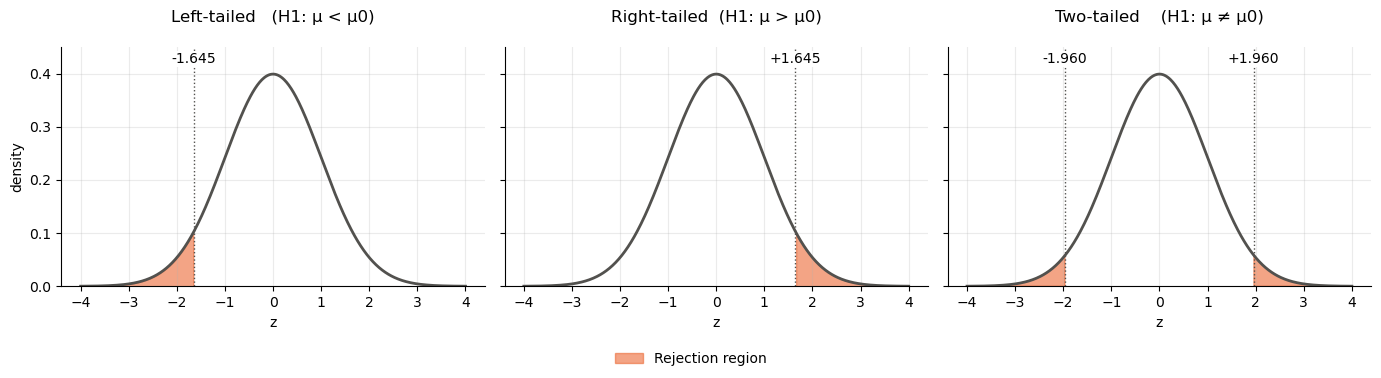

In [2]:
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
setups = [
    ('Left-tailed   (H1: μ < μ0)',  x <= stats.norm.ppf(alpha),              [stats.norm.ppf(alpha)]),
    ('Right-tailed  (H1: μ > μ0)',  x >= stats.norm.ppf(1 - alpha),          [stats.norm.ppf(1 - alpha)]),
    ('Two-tailed    (H1: μ ≠ μ0)',  abs(x) >= stats.norm.ppf(1 - alpha / 2), [-stats.norm.ppf(1 - alpha / 2),
                                                                             stats.norm.ppf(1 - alpha / 2)]),
]
for ax, (title, region, crits) in zip(axes, setups):
    ax.plot(x, y, color=CURVE, lw=2)
    ax.fill_between(x, y, where=region, color=REGION, alpha=0.6, label='Rejection region')
    for c in crits:
        ax.axvline(c, color=CURVE, ls=':', lw=1)
        ax.text(c, 0.42, f'{c:+.3f}', ha='center', fontsize=10,
                bbox=dict(facecolor='white', edgecolor='none', pad=1), zorder=5)
    ax.set_title(title, pad=18)
    ax.set_xlabel('z')
    ax.set_ylim(0, 0.45)
axes[0].set_ylabel('density')
fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=1, frameon=False)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

### Helper function to draw each test's result

It shades the rejection region for the chosen tail and marks our test statistic with a blue line.
If the blue line falls inside the orange area → **reject $H_0$**.

In [3]:
def plot_test(stat, tail, df=None, title=''):
    # tail: 'left', 'right' or 'two';  df=None -> Z (normal), otherwise t-distribution
    dist = stats.norm if df is None else stats.t(df)
    lim = max(4.5, abs(stat) + 0.8)
    x = np.linspace(-lim, lim, 600)
    y = dist.pdf(x)

    if tail == 'left':
        crits = [dist.ppf(alpha)];            region = x <= crits[0]
    elif tail == 'right':
        crits = [dist.ppf(1 - alpha)];        region = x >= crits[0]
    else:
        c = dist.ppf(1 - alpha / 2)
        crits = [-c, c];                      region = abs(x) >= c

    plt.figure()
    plt.plot(x, y, color=CURVE, lw=2)
    plt.fill_between(x, y, where=region, color=REGION, alpha=0.6, label='Rejection region')
    for c in crits:
        plt.axvline(c, color=CURVE, ls=':', lw=1)
        plt.text(c, y.max() * 1.05, f'critical = {c:+.3f}', ha='center', fontsize=9,
                 bbox=dict(facecolor='white', edgecolor='none', pad=1), zorder=5)
    plt.axvline(stat, color=STAT, lw=2.5, label=f'Test statistic = {stat:.3f}')
    plt.ylim(0, y.max() * 1.15)
    plt.title(title)
    plt.xlabel('z' if df is None else f't  (df = {df})')
    plt.ylabel('density')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    plt.show()


def decide(p_value):
    if p_value <= alpha:
        print(f"p-value = {p_value:.4f} ≤ α = {alpha}  →  REJECT H0")
    else:
        print(f"p-value = {p_value:.4f} > α = {alpha}  →  FAIL TO REJECT H0")

print("Helper functions ready.")

Helper functions ready.


---
# Part A – Z-Test  (σ known, large sample)

$$ z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}} $$

## A1. Z-Test – Left-tailed

**Problem:** A company claims its phone battery lasts **500 hours** on average (σ = 30 h is known).
A consumer group tests **36 batteries** and gets a mean of **490 hours**.
At α = 0.05, is the battery life **less than** claimed?

- $H_0: \mu = 500$
- $H_1: \mu < 500$ → keyword **"less than"** → **Left-tailed**

In [4]:
x_bar=490
Mu_0=500
sigma=30
n=36
z=(x_bar-Mu_0)/((sigma/np.sqrt(n)))
p_value=stats.norm.cdf(z)
print("Z value",z)
decide(p_value)


Z value -2.0
p-value = 0.0228 ≤ α = 0.05  →  REJECT H0


# Plot  Graph ---> (plot_test(z, tail='left'))

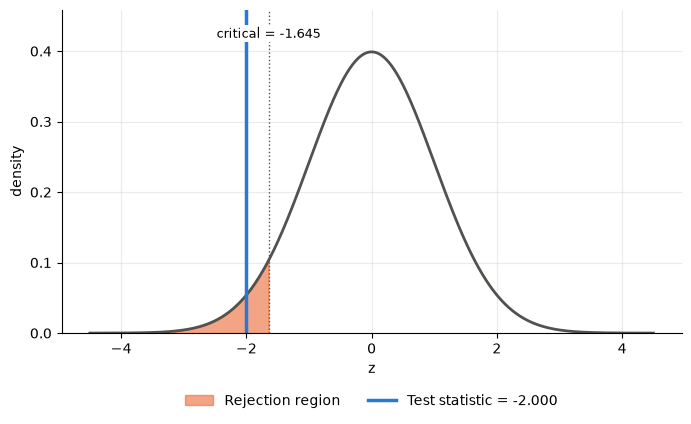

In [5]:
plot_test(z,tail="left")

**Conclusion:** $z = -2.00$ is below −1.645 (p ≈ 0.023). We **reject $H_0$** – the batteries last **less than 500 hours** on average.

## A2. Z-Test – Right-tailed

**Problem:** The average score in a national exam is **60** (σ = 12).
A coaching centre says its students score **higher**. A sample of **49 students** has a mean score of **63**.
At α = 0.05, is the coaching centre's claim supported?

- $H_0: \mu = 60$
- $H_1: \mu > 60$ → keyword **"higher"** → **Right-tailed**

In [9]:
x_bar=63
Mu_0=60
sigma=12
n=49
z=(x_bar-Mu_0)/((sigma/np.sqrt(n)))
p_value= 1-stats.norm.cdf(z)
print("Z value",z)
decide(p_value)

Z value 1.75
p-value = 0.0401 ≤ α = 0.05  →  REJECT H0


# Plot Graph ----> plot_test(z, tail='right')

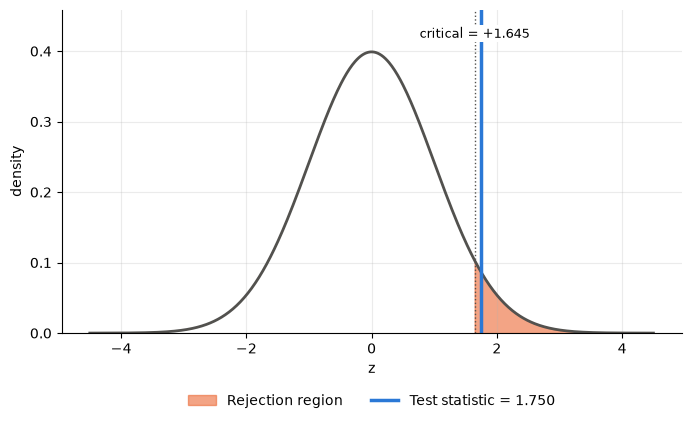

In [10]:
plot_test(z,tail="right")

**Conclusion:** $z = 1.75$ is above 1.645 (p ≈ 0.040). We **reject $H_0$** – coaching students score **higher** than 60 on average.

## A3. Z-Test – Two-tailed

**Problem:** A machine is set to fill bottles with **500 ml** (σ = 5 ml).
An inspector checks **50 bottles**: mean = **498.9 ml**.
At α = 0.05, is the machine filling a **different** amount than 500 ml?

- $H_0: \mu = 500$
- $H_1: \mu \neq 500$ → keyword **"different"** → **Two-tailed**

In [30]:
x_bar=498.9
Mu_0=500
sigma=5
n=50
z=(x_bar-Mu_0)/((sigma/np.sqrt(n)))
p_value= 2*(1-stats.norm.cdf(abs(z)))
print("Z value",z)
decide(p_value)

Z value -1.5556349186104368
p-value = 0.1198 > α = 0.05  →  FAIL TO REJECT H0


# Plot  Graph -----> plot_test(z, tail='two')

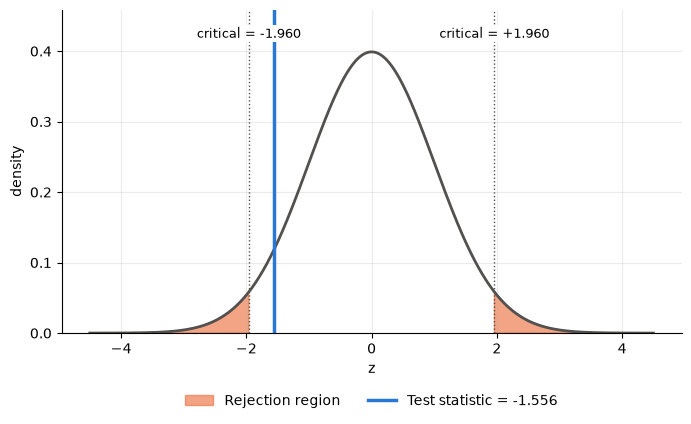

In [31]:
plot_test(z,tail="two")

**Conclusion:** $|z| = 1.56 < 1.96$ (p ≈ 0.12). We **fail to reject $H_0$** – there is **not enough evidence** that the machine is filling a different amount.
(This does *not* prove it is exactly 500 ml.)

---
# Part B – t-Test  (σ unknown, small sample)

$$ t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \qquad df = n - 1 $$

We calculate $t$ **by hand** first, then check it with SciPy's `stats.ttest_1samp()`.
The `alternative` argument matches the diagram:

| Diagram branch | `alternative=` |
|---|---|
| Left tail | `'less'` |
| Right tail | `'greater'` |
| Two-tailed | `'two-sided'` (default) |

## B1. t-Test – Left-tailed

**Problem:** A chocolate bar is labelled **100 g**. A consumer suspects the bars weigh **less**.
Weights of **10 bars** (g) are given below. Test at α = 0.05.

- $H_0: \mu = 100$
- $H_1: \mu < 100$ → **Left-tailed**

In [20]:
weights = np.array([99.6, 98.9, 100.2, 99.1, 99.8, 98.7, 99.4, 100.1, 99.0, 99.3])
x_bar=weights.mean()
Mu_0=100
s=weights.std(ddof=1)
n=len(weights)
df=n-1
t=(x_bar-Mu_0)/((s/np.sqrt(n)))
p_value=stats.t.cdf(t,df)
print("T value", t)
decide(p_value)

T value -3.667655382784775
p-value = 0.0026 ≤ α = 0.05  →  REJECT H0


# Plot 

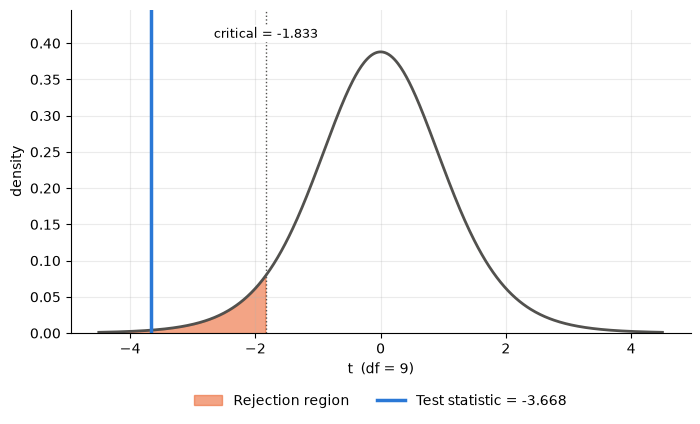

In [21]:
plot_test(t,df=df,tail="left")

**Conclusion:** $t$ is well below the critical value and p < 0.05. We **reject $H_0$** – the bars weigh **less than 100 g** on average.

## B2. t-Test – Right-tailed

**Problem:** The average exam score has been **70**. A teacher tries a new teaching method with **12 students**.
Did the new method **increase** the average score? (α = 0.05)

- $H_0: \mu = 70$
- $H_1: \mu > 70$ → **Right-tailed**

In [22]:
scores = np.array([72, 75, 68, 80, 77, 74, 71, 79, 73, 76, 69, 78])
x_bar=scores.mean()
Mu_0=70
s=scores.std(ddof=1)
n=len(scores)
df=n-1
t=(x_bar-Mu_0)/((s/np.sqrt(n)))
p_value=stats.t.cdf(t,df)
print("T value", t)
decide(p_value)

T value 3.8797721039962303
p-value = 0.9987 > α = 0.05  →  FAIL TO REJECT H0


# Plot 

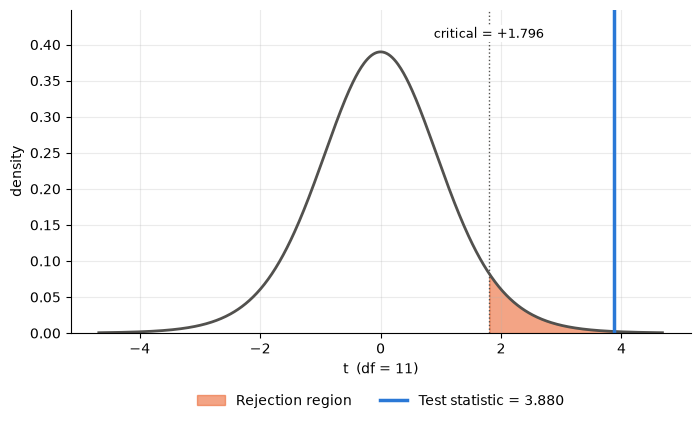

In [23]:
plot_test(t,df=df,tail="right")

**Conclusion:** $t \approx 3.88 > 1.796$ and p ≈ 0.001. We **reject $H_0$** – the new method **increased** the average score.

## B3. t-Test – Two-tailed

**Problem:** A seed company says its plants grow to **15 cm** in two weeks.
A student measures **8 plants** (cm). Is the average height **different** from 15 cm? (α = 0.05)

- $H_0: \mu = 15$
- $H_1: \mu \neq 15$ → **Two-tailed**

In [32]:
heights = np.array([15.2, 14.8, 15.5, 14.6, 15.9, 15.1, 14.7, 15.3])
x_bar=heights.mean()
Mu_0=15
s=heights.std(ddof=1)
n=len(heights)
df=n-1
t=(x_bar-Mu_0)/((s/np.sqrt(n)))
p_value=2*(1-stats.t.cdf(abs(t),df))
print("T value", t)
decide(p_value)

T value 0.8892972917998826
p-value = 0.4034 > α = 0.05  →  FAIL TO REJECT H0


# Plot 

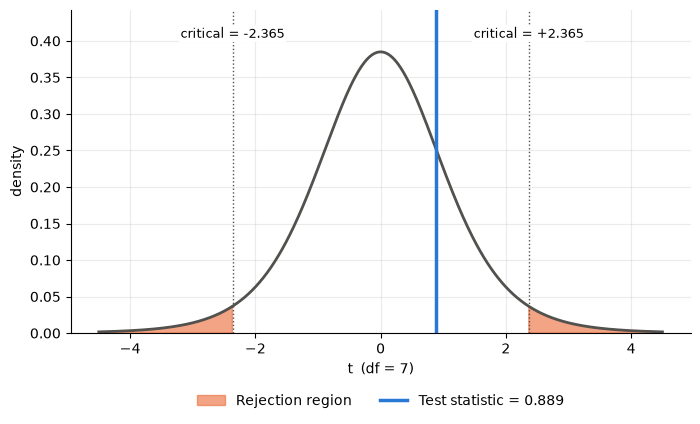

In [33]:
plot_test(t,df=df,tail="two")

**Conclusion:** $|t|$ is smaller than the critical value and p > 0.05. We **fail to reject $H_0$** – there is no evidence that the average height differs from 15 cm.

---
## 7. Summary

| Diagram branch | $H_1$ | Z-test p-value | t-test p-value | SciPy `alternative` | Critical value (α = 0.05) |
|---|---|---|---|---|---|
| **Left tail** | $\mu < \mu_0$ | `stats.norm.cdf(z)` | `stats.t.cdf(t, df)` | `'less'` | $z = -1.645$ |
| **Right tail** | $\mu > \mu_0$ | `1 - stats.norm.cdf(z)` | `1 - stats.t.cdf(t, df)` | `'greater'` | $z = +1.645$ |
| **Two-tailed** | $\mu \neq \mu_0$ | `2 * (1 - stats.norm.cdf(abs(z)))` | `2 * (1 - stats.t.cdf(abs(t), df))` | `'two-sided'` | $z = \pm 1.96$ |

### Results of our 6 examples

| Example | Test | Tail | Decision |
|---|---|---|---|
| A1 Battery life | Z | Left | Reject $H_0$ |
| A2 Coaching scores | Z | Right | Reject $H_0$ |
| A3 Bottle filling | Z | Two | Fail to reject $H_0$ |
| B1 Chocolate weight | t | Left | Reject $H_0$ |
| B2 Teaching method | t | Right | Reject $H_0$ |
| B3 Plant height | t | Two | Fail to reject $H_0$ |

### Common mistakes ⚠️
1. **Choose the tail from the question, before looking at the data.** Don't switch to one-tailed just to get a smaller p-value.
2. **Two-tailed splits α** – use α/2 in each tail (1.96, not 1.645).
3. **"Fail to reject H₀" ≠ "H₀ is true"** – it only means the evidence is not strong enough.
4. Use the **t-test when σ is unknown**, and `ddof=1` for the sample standard deviation.

## 8. Practice Questions ✍️

1. **Z-test, Left tail:** A courier claims average delivery time is **48 hours** (σ = 6). A sample of 40 deliveries averages **46 hours**. Is delivery **faster** (less time) than claimed? (α = 0.05)
2. **t-test, Right tail:** Daily screen time (hours) of 9 students: `[5.5, 6.2, 4.8, 7.1, 6.5, 5.9, 6.8, 7.4, 6.0]`. Is the mean **more than 5 hours**?
3. **t-test, Two-tailed:** The sleep (hours) of 10 students: `[6.5, 7, 5.5, 6, 7.5, 6, 5, 6.5, 7, 6]`. Is the mean **different from 7 hours**?

*Hint:* first decide the branch of the diagram (left / right / two), then reuse the code from the matching example.

Z value -2.1081851067789197
p-value = 0.0175 ≤ α = 0.05  →  REJECT H0


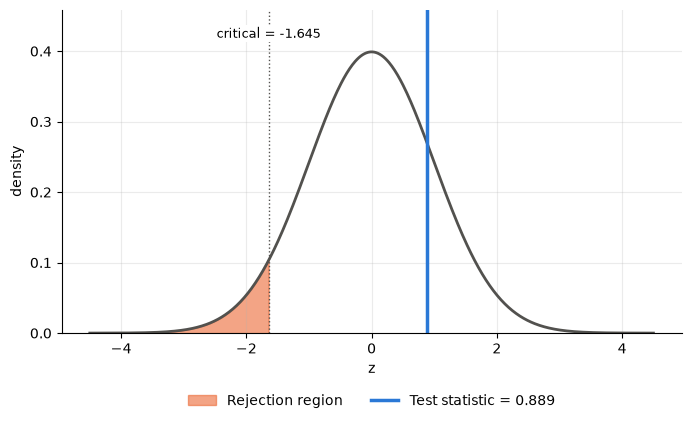

In [29]:
# Practice Question 1 – your code here
x_bar=46
Mu_0=48
sigma=6
n=40
z=(x_bar-Mu_0)/((sigma/np.sqrt(n)))
p_value = stats.norm.cdf(z)
print("Z value",z)
decide(p_value)
plot_test(t,tail="left")

In [ ]:
# Practice Question 2 – your code here

In [ ]:
# Practice Question 3 – your code here